In [784]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import math as m
from turnpike import solve_incomplete_turnpike
from simple_turnpike import solve_simple_turnpike
from itertools import combinations
import functools


## Define Class with all the relevant physics

In [785]:
class LSZ_experiment():

    def __init__(self, n_qubits, epsilon, H_target_dictionary, ramp_time, wait_time, dt, 
                 ramp_noise = False, wait_noise = False, gamma_dec_list = None, gamma_dep_list = None):
        '''
        Params:
        epsilon: Coefficient of X Hamiltonian
        alpha: Coefficient of target Hamiltonian
        total_time: Total time of the algorithm
        wait_time: Waiting time in the middle of the LSZ algorithm (0 if just doing LZ)
        max_s: maximum of s parameter. Will control slope of schedule
        '''

        #General parameters
        self.n_qubits = n_qubits
        self.e = epsilon
        self.Ht_dict = H_target_dictionary

        #Time parameters
        self.to =  0
        self.tw = wait_time
        self.tr = ramp_time
        self.dt = dt
        
        self.tf = 2*self.tr + self.tw
        self.slope = 1/self.tr

        #Noise parameters
        self.rnoise = ramp_noise
        self.wnoise = wait_noise
        self.dec_rates = gamma_dec_list
        self.dep_rates = gamma_dep_list

        #Initialize pauli operators
        self.npsx, self.npsy, self.npsz = np.array([[0, 1], [1, 0]]), np.array([[0, -1j], [1j, 0]]), np.array([[1, 0], [0, -1]])
        self.qtsx, self.qtsy, self.qtsz = qt.sigmax(), qt.sigmay(), qt.sigmaz() 

        self.ket0 = qt.basis(2, 0)
        self.ket1 = qt.basis(2, 1)

        self.qtsx_list, self.qtsy_list, self.qtsz_list = self.initialize_qt_operators()
        self.npsx_list, self.npsy_list, self.npsz_list = self.initialize_np_operators()

       #Build Hamiltonians 
        self.H0_numpy = self.build_H0_numpy()
        self.H0_qutip = self.build_H0_qutip()

        self.Ht_numpy = self.build_Ht_numpy()
        self.Ht_qutip = self.build_Ht_qutip()

        #Initialize noise operators
        self.dep_ops, self.dec_ops = None, None
        if self.rnoise or self.wnoise:
            self.dep_ops, self.dec_ops = self.build_noise_operators()

    
    def kron_n(self, ops):
        '''Tensor product of a list of operators'''
        out = ops[0]
        for A in ops[1:]:
            out = np.kron(out, A)
        return out
    
    def build_H0_numpy(self):
        H = np.zeros((2**self.n_qubits, 2**self.n_qubits))
        for i in range(self.n_qubits):
            H += -self.e*self.npsx_list[i]
        return H

    def build_H0_qutip(self):
        H = 0
        for i in range(self.n_qubits):
            H += -self.e*self.qtsx_list[i]
        return H
    
    def build_Ht_numpy(self):
        #Initialize Hamiltonian
        H = np.zeros((2**self.n_qubits, 2**self.n_qubits))
        local_z_terms = self.Ht_dict['one_body']

        #Add 1-body terms
        for i, weight in enumerate(local_z_terms):
            H += weight*self.npsz_list[i]

        #Add 2-body terms only if more than 1 qubit
        if self.n_qubits > 1:
            zz_terms = self.Ht_dict['two_body']

            #Apply to all qubit pairs 
            k = 0
            for i in range(self.n_qubits-1):
                for j in range(i+1, self.n_qubits):
                    H += zz_terms[k] * self.npsz_list[i] @ self.npsz_list[j]
                    k += 1

        return H

    def build_Ht_qutip(self):
        #Initialize Hamiltonian
        H = 0
        local_z_terms = self.Ht_dict['one_body']

        #Add 1-body terms
        for i, weight in enumerate(local_z_terms):
            H += weight*self.qtsz_list[i]

        #Add 2-body terms only if more than 1 qubit
        if self.n_qubits > 1:
            zz_terms = self.Ht_dict['two_body']

            #Apply to all qubit pairs
            k = 0
            for i in range(self.n_qubits-1):
                for j in range(i+1, self.n_qubits):
                    H += zz_terms[k] * self.qtsz_list[i] * self.qtsz_list[j]
                    k += 1

        return H

    def initialize_np_operators(self):
        '''Setup operators for individual qubits
            for each value of i it puts the paulis in different positions of the list, 
            then does IxIxI...sigma_ixIxI...xI
        '''
        sx_list, sy_list, sz_list = [], [], []
        sx, sy, sz = self.npsx, self.npsy, self.npsz
        for i in range(self.n_qubits):
            #list of 2x2 identity matrices
            op_list = [np.eye(2) for _ in range(self.n_qubits)]
            #replace i-th element with sigma_x
            op_list[i] = sx
            #create matrices of 2^Nx2^N
            sx_list.append(self.kron_n(op_list))
            #do the same for sigma_y and sigma_z
            op_list[i] = sy
            sy_list.append(self.kron_n(op_list))
            op_list[i] = sz
            sz_list.append(self.kron_n(op_list))

        return sx_list, sy_list, sz_list

    def initialize_qt_operators(self):
        '''Setup operators for individual qubits
            for each value of i it puts the paulis in different positions of the list, 
            then does IxIxI...sigma_ixIxI...xI
        '''
        sx_list, sy_list, sz_list = [], [], []
        sx, sy, sz = self.qtsx, self.qtsy, self.qtsz
        for i in range(self.n_qubits):
            #list of 2x2 identity matrices
            op_list = [qt.qeye(2)] * self.n_qubits
            #replace i-th element with sigma_x
            op_list[i] = sx
            #create matrices of 2^Nx2^N
            sx_list.append(qt.tensor(op_list))
            #do the same for sigma_y and sigma_z
            op_list[i] = sy
            sy_list.append(qt.tensor(op_list))
            op_list[i] = sz
            sz_list.append(qt.tensor(op_list))

        return sx_list, sy_list, sz_list
    
    def build_noise_operators(self):

        #Build dephasing and decay operators separately
        if self.dep_rates:
            dep_ops = []
            for i in range(self.n_qubits):
                dep_ops.append(np.sqrt(self.dep_rates[i])*self.qtsz_list[i])
        else:
            dep_ops = None  

        if self.dec_rates:  
            dec_ops = []
            for i in range(self.n_qubits):
                #Build sigma minus operator first
                op_list = [qt.qeye(2)] * self.n_qubits
                op_list[i] = qt.sigmam()
                dec_ops.append(np.sqrt(self.dec_rates[i])*qt.tensor(op_list))
        else:
            dec_ops = None
        
        return dep_ops, dec_ops


    def trapezoid_s(self, t):
        return np.minimum(1, self.slope * np.minimum(t, self.tf - t))

    def H_numpy(self, t):
        s = self.trapezoid_s(t)
        return (1-s)*self.H0_numpy + s*self.Ht_numpy
    
    def H_qutip(self):

        H = [[self.H0_qutip, lambda t, args: 1 - self.trapezoid_s(t)], [self.Ht_qutip, lambda t, args: self.trapezoid_s(t)]]

        return H
    
    
    def show_schedule(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        s_list = np.zeros(len(t_list))

        for i,t in enumerate(t_list):
            s_list[i] = self.trapezoid_s(t)
        
        return t_list, s_list
    
    def show_spectrum(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        eg_val_list = []
        eg_vec_list = []

       #Diagonalize for each time step 
        for i,t in enumerate(t_list):
            H = self.H_numpy(t)
            egvals, egvecs = np.linalg.eigh(H)

            eg_val_list.append(egvals)
            eg_vec_list.append(egvecs)

        return t_list, eg_val_list, eg_vec_list
    
        #takes optional noise variable for two phases and operators
    def time_evolution(self):
        #Lists of time grids 3 phases of computation
        t_list_r1 = np.linspace(self.to, self.tr, max(100, int(self.tr / self.dt)))
        t_list_w = np.linspace(self.tr, self.tr + self.tw, max(100, int(self.tw / self.dt)))
        t_list_r2 = np.linspace(self.tr + self.tw, self.tf, max(100, int(self.tr / self.dt)))

        #Prepare ground state of H at time 0
        psi0 = qt.tensor([1/np.sqrt(2)*(self.ket0 + self.ket1)]*self.n_qubits)

        #Initialize qutip Hamiltonian
        H = self.H_qutip()

        #Time evolution
        dep_ops = self.dep_ops or []
        dec_ops = self.dec_ops or []
        ramp_c_ops = dep_ops + dec_ops if self.rnoise else []
        wait_c_ops = dep_ops + dec_ops if self.wnoise else []

        # Segment 1: pure unitary if ramp is noiseless, else Lindblad.
        if self.rnoise:
            sim_r1 = qt.mesolve(H, psi0, t_list_r1, c_ops=ramp_c_ops)
        else:
            sim_r1 = qt.sesolve(H, psi0, t_list_r1)

        # Segment 2: same logic for the wait.
        if self.wnoise:
            sim_w = qt.mesolve(H, sim_r1.states[-1], t_list_w, c_ops=wait_c_ops)
        else:
            sim_w = qt.sesolve(H, sim_r1.states[-1], t_list_w)

        # Segment 3: if ANY prior segment was noisy, we have a density matrix —
        # must stay in mesolve (with empty c_ops = exact unitary) for the final ramp.
        # If everything has been noiseless up to here, stay in sesolve.
        downstream_noisy = self.wnoise or self.rnoise
        if self.rnoise:
            sim_r2 = qt.mesolve(H, sim_w.states[-1], t_list_r2, c_ops=ramp_c_ops)
        elif downstream_noisy:
            sim_r2 = qt.mesolve(H, sim_w.states[-1], t_list_r2, c_ops=[])
        else:
            sim_r2 = qt.sesolve(H, sim_w.states[-1], t_list_r2)

        return sim_r1, sim_w, sim_r2

    
    def calculate_populations(self, sim_res):
        H_f = self.H_numpy(self.tf)
        eigvals_f, eigvecs_f = np.linalg.eigh(H_f)

        n_states = 2**self.n_qubits
        populations = np.zeros(n_states)
        final = sim_res.states[-1]

        #Handle pure and mixed states differently (ideal vs. noisy)
        if final.type == 'ket':
            final_state = final.full().flatten()
            for k in range(n_states):
                overlap = np.dot(eigvecs_f[:, k].conj(), final_state)
                populations[k] = np.real(overlap * overlap.conj())
        else:
            rho = final.full()
            for k in range(n_states):
                v = eigvecs_f[:, k].reshape(-1, 1)
                populations[k] = np.real(v.conj().T @ rho @ v).item()

        return populations



- Ramp time controls the speed that we use to bring the system to the middle point. The faster, the higher the transition probability.

- High ramp time makes oscillations larger

- for LZ we ramp and pass the crossing once. For LZS you cross the gap twice. during wait time, s=1, no transverse term. Start at Hx, both terms evolve.


## Define parameters of experiment

In [ ]:
epsilon = 1 #Relative weight of transverse field in total hamiltonian
alpha = 0.4 #Related to max wait time
ramp_time = 0.75
n_steps = 201 #For spectrum plots
dt = 0.05 #For simulations
r_noise = False
w_noise = False


#1 qubit example
# local_z_list = np.array([1])
# zz_terms = np.array([])

#2 qubit example (GHz)
# local_z_list = np.array([2.1,1.1])
# zz_terms = np.array([0.35])

# t1_rates = [0.11, 0.1]
# t2_rates = [0.01, 0.015]
#t2_rates = [1e-12, 1e-12]

#3 qubit example
# local_z_list = np.array([2.1, 3.05, 1.78])
# zz_terms = np.array([1.22, 0.54, 0.3])

# t1_rates = [0.005, 0.0051, 0.0048]
# t2_rates = [0.01, 0.012, 0.0098]

# local_z_list = np.array([3.836, 2.22, 0.71])
# zz_terms = np.array([1.298, 0.303, 0.16])

local_z_list = np.array([2.124, 3.926, 1.289])
zz_terms = np.array([1.772, 0.08, 0.563])

t1_rates = [0.005, 0.0051, 0.0048]
t2_rates = [0.01, 0.012, 0.0098]

#4 qubit example
# local_z_list = np.array([1.1, 2.05, 1.44, 0.93])
# zz_terms = np.array([2.82, 1.24, 0.36, 3.22, 1.48, 3.20])

nqubits = len(local_z_list)
max_wait_time = 50.0/alpha
n_sims = int(max_wait_time*20) #Number of runs

tw_l = np.linspace(0, max_wait_time, n_sims)
pc_list = []
pe_list = []


H_target_dict = {'one_body': local_z_list, 'two_body': zz_terms}

wait_test = 0
test =LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, wait_test, dt)

print("Max wait time:", max_wait_time)
print("dt:", dt)
print("Number of simulations:", n_sims)

Max wait time: 250.0
dt: 0.05
Number of simulations: 5000


## Plot example schedue

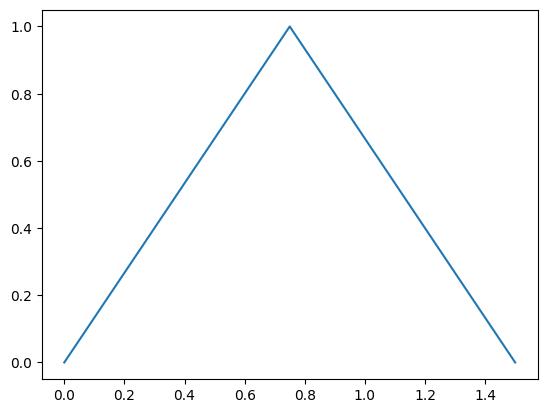

In [787]:
t_list, s_list = test.show_schedule(n_steps)
plt.plot(t_list, s_list)

## Plot evolution of real spectrum

[-4.924 -4.38  -3.632 -2.768 -1.742  1.802  5.89   9.754]
[np.float64(0.11600000000000055), np.float64(0.16199999999999926), np.float64(0.20400000000000063), np.float64(0.2240000000000011), np.float64(0.2659999999999998), np.float64(0.2659999999999998), np.float64(0.2779999999999998), np.float64(0.3200000000000003), np.float64(0.3200000000000003), np.float64(0.3200000000000012), np.float64(0.3619999999999992), np.float64(0.4819999999999993), np.float64(0.4820000000000002), np.float64(0.5439999999999987), np.float64(0.5439999999999987), np.float64(0.5439999999999996), np.float64(0.5440000000000005), np.float64(0.6819999999999986), np.float64(0.7059999999999995), np.float64(0.7479999999999993), np.float64(0.7479999999999993), np.float64(0.7480000000000011), np.float64(0.8640000000000008), np.float64(0.8640000000000008), np.float64(0.8640000000000008), np.float64(0.9060000000000006), np.float64(1.0260000000000016)]


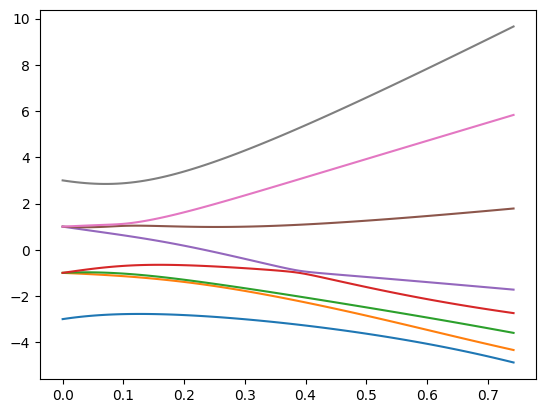

In [788]:
t_list, egvals, egvecs = test.show_spectrum(n_steps)
midpoint = int(len(t_list)/2)
plt.plot(t_list[0:midpoint], egvals[0:midpoint])

print(egvals[midpoint])

true_differences = []
for i in range(len(egvals[midpoint])):
    for j in range(i+1, len(egvals[midpoint])):
        true_differences.append(egvals[midpoint][j] - egvals[midpoint][i])
true_differences = np.array(true_differences)

peak_separations = []
for i in range(len(sorted(true_differences)[1:])):
    peak_separations.append(sorted(true_differences)[i+1] - sorted(true_differences)[i])

print(sorted(peak_separations))


## Run loop over all waiting times

In [789]:
for wait_time in tw_l:
    experiment =LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, wait_time, dt,
                               ramp_noise= r_noise, wait_noise= w_noise,
                               gamma_dec_list=None, gamma_dep_list=t2_rates)
    
    ramp1_sim, wait_sim, ramp_2_sim = experiment.time_evolution()

    populations = experiment.calculate_populations(ramp_2_sim)

    pc_list.append(np.real(populations[0]))

### Definition of Fourier analysis function

In [790]:
def fourier_analysis(pc_list, tw_l, n_peaks=28, prominence_threshold=0.01,
                     zero_pad_factor=32, window='hann'):
    """
    High-resolution spectral analysis returning frequencies and phases of all
    detected modes. Amplitudes and decay rates are left for fit_decay_rates.

    Returns
    -------
    experimental_freqs : np.ndarray   shape (K,)
    phases : np.ndarray               shape (K,)
    """
    from scipy.signal import find_peaks, get_window

    y = np.asarray(pc_list, dtype=float)
    t = np.asarray(tw_l, dtype=float)
    N = len(y)
    dt = t[1] - t[0]
    dc = y.mean()

    win = get_window(window, N)
    cg = win.sum() / N
    y_win = (y - dc) * win

    N_pad = zero_pad_factor * N
    spectrum = np.fft.rfft(y_win, n=N_pad)
    freqs = np.fft.rfftfreq(N_pad, dt)
    magnitude = np.abs(spectrum)

    mag = magnitude[1:]
    frq = freqs[1:]
    spc = spectrum[1:]

    min_dist = max(1, zero_pad_factor // 2)
    peak_locs, _ = find_peaks(mag, distance=min_dist, prominence=0.02 * mag.max())
    if len(peak_locs) == 0:
        peak_locs = np.array([np.argmax(mag)])

    threshold = prominence_threshold * mag[peak_locs].max()
    peak_locs = peak_locs[mag[peak_locs] >= threshold]

    order = np.argsort(mag[peak_locs])[::-1]
    peak_locs = peak_locs[order[:n_peaks]]

    log_mag = np.log(mag + 1e-30)
    freqs_refined = np.empty(len(peak_locs))
    phases        = np.empty(len(peak_locs))
    amplitudes_fft = np.empty(len(peak_locs))

    for i, k in enumerate(peak_locs):
        k_l = max(k - 1, 0)
        k_r = min(k + 1, len(mag) - 1)
        a_, b_, c_ = log_mag[k_l], log_mag[k], log_mag[k_r]
        if k_l != k_r:
            delta = 0.5 * (a_ - c_) / (a_ - 2*b_ + c_ + 1e-30)
            delta = np.clip(delta, -1.0, 1.0)
        else:
            delta = 0.0

        df = frq[1] - frq[0]
        freqs_refined[i] = frq[k] + delta * df

        amp_interp = mag[k] if delta == 0 else (
            mag[k_l] * (1 - abs(delta)) + mag[min(k_r, len(mag)-1)] * abs(delta))
        amplitudes_fft[i] = 2.0 * amp_interp / (N * cg)

        phase_raw = np.angle(spc[k])
        phases[i] = (phase_raw - 2 * np.pi * freqs_refined[i] * t[0]) % (2 * np.pi)

    order2 = np.argsort(amplitudes_fft)[::-1]
    freqs_refined = freqs_refined[order2]
    phases        = phases[order2]
    amplitudes_fft = amplitudes_fft[order2]

    # Plot spectrum
    x_max = freqs_refined.max() * 1.2
    colors = plt.cm.tab10.colors
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.plot(frq, mag, color='#cc4444', lw=1.2)
    for i, f in enumerate(freqs_refined):
        ax.axvline(f, color=colors[i % len(colors)], lw=1.0, linestyle='--', alpha=0.8)
    ax.set_xlabel('Frequency')
    ax.set_ylabel('|FFT|')
    ax.set_xlim(0, x_max)
    ax.set_title('Spectrum')
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.bar(range(len(amplitudes_fft)), amplitudes_fft,
           color=[colors[i % len(colors)] for i in range(len(amplitudes_fft))])
    ax.set_xlabel('Mode index')
    ax.set_ylabel('FFT Amplitude')
    ax.set_title('Mode Amplitudes (FFT)')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print(f"\n{'#':>3}  {'Frequency':>14}  {'Phase (rad)':>12}")
    print("-" * 35)
    for i, (f, p) in enumerate(zip(freqs_refined, phases)):
        print(f"{i+1:>3}  {f:>14.6f}  {p:>12.4f}")

    return freqs_refined, phases


def fit_decay_rates(pc_list, tw_l, freqs_detected, phases_detected, noise=True):
    """
    Fit amplitudes (and optionally decay rates) and DC offset globally to:

        y(t) = DC + sum_k  A_k * exp(-lambda_k * t) * cos(2*pi*f_k*t + phi_k)

    Frequencies and phases are fixed from fourier_analysis.

    Parameters
    ----------
    noise : bool
        If True, fit amplitudes A_k and decay rates lambda_k jointly.
        If False, fit only amplitudes (and DC); lambdas pinned to 1e-12 so
        downstream cells that consume `lambdas` still work without division
        errors. Use this when the signal is noiseless — fitting lambdas on a
        noiseless signal can absorb FFT leakage of spurious peaks into large
        fake decay rates and bias the amplitudes of real peaks.
    """
    from scipy.optimize import curve_fit

    y = np.asarray(pc_list, dtype=float)
    t = np.asarray(tw_l, dtype=float)
    omegas = 2 * np.pi * freqs_detected
    K = len(freqs_detected)

    if noise:
        def model(t, dc, *params):
            A_k   = params[0::2]
            lam_k = params[1::2]
            out = np.full_like(t, dc)
            for A, lam, omega, phi in zip(A_k, lam_k, omegas, phases_detected):
                out += 2*A * np.exp(-lam * t) * np.cos(omega * t + phi)
            return out

        p0 = np.empty(1 + 2 * K)
        p0[0]    = y.mean()
        p0[1::2] = 0.05
        p0[2::2] = 1e-3

        lb = np.zeros(1 + 2 * K)
        ub = np.full(1 + 2 * K, np.inf)

        popt, _ = curve_fit(model, t, y, p0=p0, bounds=(lb, ub),
                            maxfev=100000, xtol=1e-10, ftol=1e-10)

        dc_fit     = popt[0]
        amplitudes = popt[1::2]
        lambdas    = popt[2::2]
        y_fit      = model(t, *popt)
    else:
        def model(t, dc, *A_k):
            out = np.full_like(t, dc)
            for A, omega, phi in zip(A_k, omegas, phases_detected):
                out += 2*A * np.cos(omega * t + phi)
            return out

        p0 = np.empty(1 + K)
        p0[0]  = y.mean()
        p0[1:] = 0.05

        lb = np.zeros(1 + K)
        ub = np.full(1 + K, np.inf)

        popt, _ = curve_fit(model, t, y, p0=p0, bounds=(lb, ub),
                            maxfev=100000, xtol=1e-10, ftol=1e-10)

        dc_fit     = popt[0]
        amplitudes = popt[1:]
        lambdas    = np.full(K, 1e-12)
        y_fit      = model(t, *popt)

    plt.figure(figsize=(8, 3))
    plt.plot(t, y, 'b-', lw=1, alpha=0.6, label='data')
    plt.plot(t, y_fit, 'r--', lw=1.5, label='fit')
    rms = np.sqrt(np.mean((y - y_fit)**2))
    plt.title(f'Global fit  (RMS residual = {rms:.5f},  DC = {dc_fit:.4f})')
    plt.xlabel('Time')
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    return amplitudes, lambdas, dc_fit


## Plot results of Fourier analysis

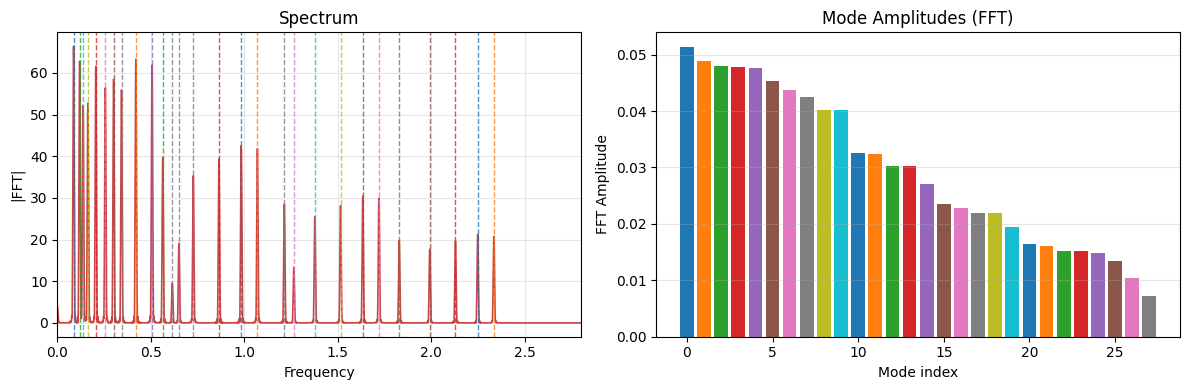


  #       Frequency   Phase (rad)
-----------------------------------
  1        0.086585        0.3380
  2        0.419850        1.9374
  3        0.119054        0.4470
  4        0.205627        0.7869
  5        0.506431        2.2755
  6        0.300801        1.4885
  7        0.256558        0.9253
  8        0.343139        2.0491
  9        0.163292        1.0131
 10        0.137494        0.4773
 11        0.983896        4.7204
 12        1.070475        5.0585
 13        0.564046        2.7832
 14        0.864848        4.2717
 15        0.727338        3.7953
 16        1.634521        1.4744
 17        1.721102        2.5981
 18        1.214671        5.8202
 19        1.515473        1.0257
 20        1.377964        0.5492
 21        2.249504        4.4941
 22        2.336084        4.8329
 23        1.829653        2.5566
 24        2.130456        4.0455
 25        0.650623        3.0372
 26        1.992947        3.5682
 27        1.265606        6.0571
 28        

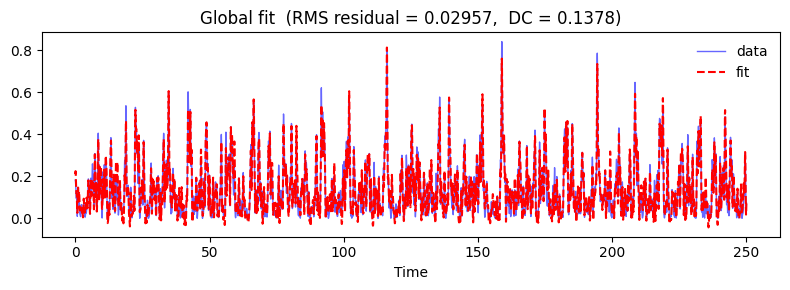

Amplitudes: [0.02531078 0.02520614 0.02446535 0.0236701  0.02342347 0.02329089
 0.02169334 0.02221511 0.02061837 0.01976381 0.01689968 0.01625736
 0.01591164 0.01565701 0.01324881 0.01212775 0.01131553 0.01133815
 0.01111337 0.01001015 0.00844172 0.00786925 0.00792822 0.00777304
 0.00757238 0.00684339 0.00529524 0.00384625]
Decay rates: [1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12
 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12
 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12]
DC (fitted): 0.13775453489892567   DC (mean): 0.13655130148894296


In [791]:
experimental_freqs, experimental_phases = fourier_analysis(
    pc_list, tw_l, n_peaks=(2**nqubits)*(2**nqubits-1)//2,
    prominence_threshold=0.01,zero_pad_factor=4, window='hann'
)
# Set noise=True to jointly fit decay rates; noise=False forces lambdas to 1e-12
# and only fits amplitudes (use when the signal is noiseless).
experimental_amps, lambdas, dc_fit = fit_decay_rates(
    pc_list, tw_l, experimental_freqs, experimental_phases, noise=w_noise
)

print("Amplitudes:", experimental_amps)
print("Decay rates:", lambdas)
print("DC (fitted):", dc_fit, "  DC (mean):", np.mean(pc_list))


## Comparison with exact Hamiltonian

Including functions to present results nicely


                     Matched energy differences                     
--------------------------------------------------------------------
   #     Detected Δε         True Δε           Error       Error (%)
--------------------------------------------------------------------
   1        0.544032        0.544000       +0.000032          +0.006%
   2        2.637997        2.638000       -0.000003          -0.000%
   3        0.748040        0.748000       +0.000040          +0.005%
   4        1.291995        1.292000       -0.000005          -0.000%
   5        3.181998        3.182000       -0.000002          -0.000%
   6        1.889988        1.890000       -0.000012          -0.001%
   7        1.612003        1.612000       +0.000003          +0.000%
   8        2.156003        2.156000       +0.000003          +0.000%
   9        1.025992        1.026000       -0.000008          -0.001%
  10        0.863903        0.864000       -0.000097          -0.011%
  11        6.182003   

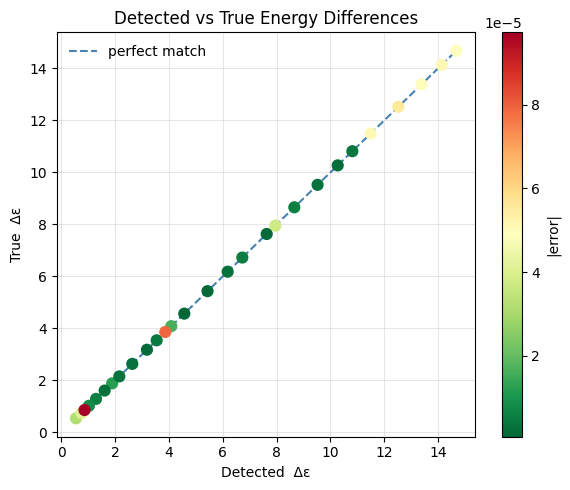

In [792]:
def table_printout(matched_detected, matched_true, residuals, true_differences, col_idx):
    # --- Nice table printout ---
    col_w = 14
    header = f"{'#':>4}  {'Detected Δε':>{col_w}}  {'True Δε':>{col_w}}  {'Error':>{col_w}}  {'Error (%)':>{col_w}}"
    sep    = "-" * len(header)
    print(f"\n{'Matched energy differences':^{len(header)}}")
    print(sep)
    print(header)
    print(sep)
    for i, (d, tr, res) in enumerate(zip(matched_detected, matched_true, residuals)):
        pct = res / tr * 100 if tr != 0 else 0.0
        print(f"{i+1:>4}  {d:{col_w}.6f}  {tr:{col_w}.6f}  {res:+{col_w}.6f}  {pct:+{col_w}.3f}%")
    print(sep)
    rms_err = np.sqrt(np.mean(residuals**2))
    print(f"{'RMS error:':>{col_w + 4 + col_w + 2}}  {rms_err:{col_w}.6f}")

    # Unmatched true differences (modes not detected)
    unmatched_true = np.delete(true_differences, col_idx)
    if len(unmatched_true) > 0:
        print(f"\nUnmatched true differences: {np.round(unmatched_true, 6)}")

def scatter_plot(matched_detected, matched_true, residuals):
    # --- Scatter plot ---
    diag_vals = np.linspace(min(matched_true.min(), matched_detected.min()),
                            max(matched_true.max(), matched_detected.max()), 100)


    plt.figure(figsize=(6, 5))
    sc = plt.scatter(matched_detected, matched_true, c=np.abs(residuals),
                    cmap='RdYlGn_r', s=60, zorder=3)
    plt.colorbar(sc, label='|error|')
    plt.plot(diag_vals, diag_vals, '--', c='steelblue', lw=1.5, label='perfect match')
    plt.xlabel('Detected  Δε')
    plt.ylabel('True  Δε')
    plt.title('Detected vs True Energy Differences')
    plt.legend(frameon=False)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

experimental_energy_diffs = 2 * np.pi * experimental_freqs

true_differences = []
for i in range(len(egvals[midpoint])):
    for j in range(i+1, len(egvals[midpoint])):
        true_differences.append(egvals[midpoint][j] - egvals[midpoint][i])
true_differences = np.array(true_differences)

# --- Nearest-neighbour matching between detected and true differences ---
from scipy.optimize import linear_sum_assignment

n_det  = len(experimental_energy_diffs)
n_true = len(true_differences)

# Cost matrix: |e_diff_i - true_diff_j|
cost = np.abs(experimental_energy_diffs[:, None] - true_differences[None, :])
row_idx, col_idx = linear_sum_assignment(cost)

matched_detected = experimental_energy_diffs[row_idx]
matched_true     = true_differences[col_idx]
residuals        = matched_detected - matched_true

table_printout(matched_detected, matched_true, residuals, true_differences, col_idx)

scatter_plot(matched_detected, matched_true, residuals)

## Solve turnpike problem to find spectrum

In [793]:
solutions = solve_incomplete_turnpike(experimental_energy_diffs, n_levels=2**nqubits)
#print(experimental_energy_diffs)
#solutions = solve_simple_turnpike(experimental_energy_diffs, 2**nqubits, slack=1)


Incomplete Turnpike Solver
  Target levels:        8
  Expected differences: 28
  Observed differences: 28 (100%)

  Trying match threshold = 100% ... found solution explaining 28/28 (100%) of observations.

  Running greedy solver for comparison...
  Greedy explains 28/28 (100%)

  Final solution (backtracking):
    [np.float64(0.0), np.float64(0.544), np.float64(1.292), np.float64(2.156), np.float64(3.182), np.float64(6.726), np.float64(10.814), np.float64(14.678)]
    Explains 28/28 observed differences (100%)



## Compare spectrum with real one

                  E0      E1      E2      E3      E4      E5      E6      E7
True:         0.0000  0.5440  1.2920  2.1560  3.1820  6.7260 10.8140 14.6780
Forward:      0.0000  0.5440  1.2920  2.1560  3.1820  6.7260 10.8140 14.6780  <-- best
Reversed:     0.0000  3.8640  7.9520 11.4961 12.5221 13.3860 14.1341 14.6780


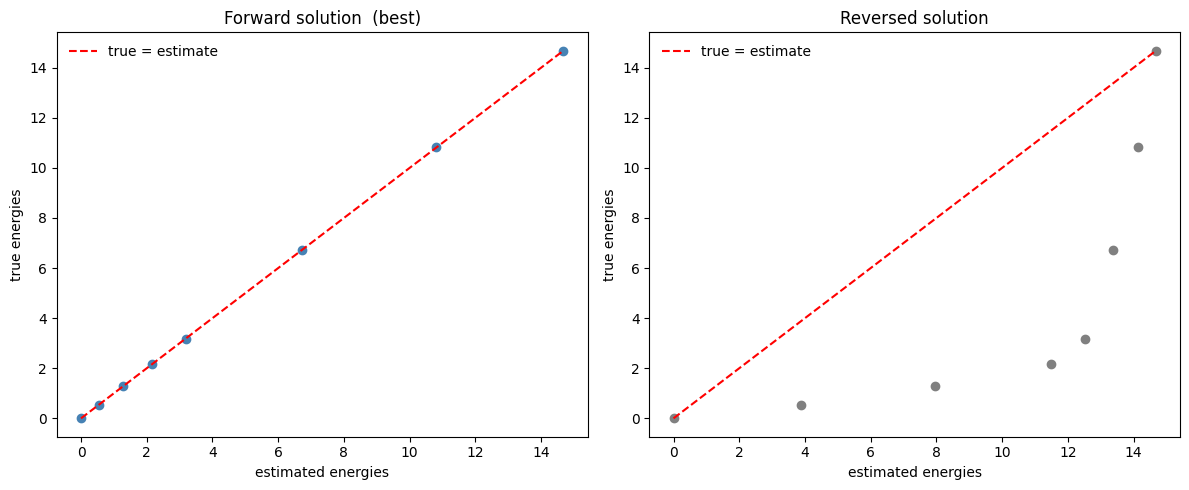

In [794]:
true_energies = egvals[midpoint]
shifted_true_energies = np.array([e - true_energies[0] for e in true_energies])

# Both turnpike solutions: forward and reversed (mirror symmetry)
levels = np.array(solutions['levels'])
levels_rev = np.max(levels) - levels[::-1]  # mirror around midpoint, shifted to start at 0

candidates = {'Forward': levels, 'Reversed': levels_rev}

# Pick best candidate by RMS error against true spectrum (sorted comparison)
def rms_error(est, true):
    return np.sqrt(np.mean((np.sort(est) - np.sort(true))**2))

best_label = min(candidates, key=lambda k: rms_error(candidates[k], shifted_true_energies))
experimental_energies = candidates[best_label]

# --- Table printout ---
col_w = 8
header = "".join(f"{'E'+str(i):>{col_w}}" for i in range(len(shifted_true_energies)))
print(f"{'':12}{header}")
print(f"{'True:':12}{''.join(f'{v:{col_w}.4f}' for v in shifted_true_energies)}")
for label, lvls in candidates.items():
    marker = '  <-- best' if label == best_label else ''
    print(f"{label+':':12}{''.join(f'{v:{col_w}.4f}' for v in lvls)}{marker}")

# --- Scatter plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, lvls) in zip(axes, candidates.items()):
    diag = np.linspace(np.min(lvls), np.max(lvls), 100)
    ax.scatter(np.sort(lvls), np.sort(shifted_true_energies),
               color='steelblue' if label == best_label else 'gray')
    ax.plot(diag, diag, "--", c="red", label="true = estimate")
    ax.set_xlabel("estimated energies")
    ax.set_ylabel("true energies")
    ax.set_title(f"{label} solution{'  (best)' if label == best_label else ''}")
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Create Transition matrices

In [795]:
def create_transition_matrices(experimental_energies, experimental_energy_diffs, experimental_amps, experimental_phases, experimental_decays):
    n = len(experimental_energies)
    w_mn = np.zeros((n, n))
    w_predicted = np.zeros((n, n))
    a_mn = np.zeros((n, n))
    d_mn = np.zeros((n, n))
    lmd_mn = np.zeros((n, n))
    # Build predicted upper-triangle frequency differences
    for i in range(n - 1):
        for j in range(i + 1, n):
            w_predicted[i, j] = experimental_energies[j] - experimental_energies[i]

    # Mask: restrict search to upper triangle only (i < j).
    # Without this, the zeros in the diagonal and lower triangle contaminate
    # np.argmin for any diff > 0, causing wrong (i, j) assignments.
    upper_tri_mask = np.zeros((n, n), dtype=bool)
    for i in range(n - 1):
        for j in range(i + 1, n):
            upper_tri_mask[i, j] = True

    used = set()  # ensure each (i, j) cell is assigned at most once

    for idx, diff in enumerate(experimental_energy_diffs):
        # Distance only over upper-triangle; set everything else to inf
        dist = np.where(upper_tri_mask, np.abs(w_predicted - diff), np.inf)

        # Walk candidates in ascending distance order; skip already-used cells
        ij_pairs = [np.unravel_index(k, (n, n)) for k in np.argsort(dist, axis=None)]
        for i, j in ij_pairs:
            i, j = int(i), int(j)
            if dist[i, j] == np.inf:
                break  # no valid upper-triangle cell left
            if (i, j) not in used:
                used.add((i, j))
                a_mn[i, j] = experimental_amps[idx]
                d_mn[i, j] = experimental_phases[idx]
                w_mn[i, j] = diff
                lmd_mn[i, j] = experimental_decays[idx]
                break

    return w_mn, a_mn, d_mn, lmd_mn, w_predicted

## Compute phases and state vector

In [796]:
from itertools import combinations
from collections import deque


def compute_u_m(a_mn):
    """
    Estimate amplitudes |u_m| from the transition amplitude matrix a_mn.

    For each level m and every pair (n, o) where all three entries are nonzero:
        u_m_candidate = (a[m,n] * a[m,o] / (2 * a[n,o]))^(1/4)

    Returns the median over all valid candidates, which is robust to a single
    outlier amplitude (as long as fewer than half the triplets are contaminated).
    """
    N = a_mn.shape[0]
    u_m = np.full(N, np.nan)

    for m in range(N):
        others = [k for k in range(N) if k != m]
        estimates = []
        for n, o in combinations(others, 2):
            a_mn_val = a_mn[min(m, n), max(m, n)]
            a_mo_val = a_mn[min(m, o), max(m, o)]
            a_no_val = a_mn[min(n, o), max(n, o)]
            if a_mn_val > 0 and a_mo_val > 0 and a_no_val > 0:
                estimates.append((a_mn_val * a_mo_val / (a_no_val)) ** 0.25)
        if estimates:
            u_m[m] = np.median(estimates)
        else:
            print(f"Warning: no valid triangle for m={m}; u_m[{m}] set to NaN.")

    return u_m


def compute_phi_m(d_mn):
    """
    Estimate phases phi_m mod pi via BFS over the detected-transition graph.
    d_mn[i,j] = 2*(phi_i - phi_j), phi_0 fixed to 0.
    """
    N = d_mn.shape[0]
    phi_m = np.full(N, np.nan)
    phi_m[0] = 0.0
    visited = [False] * N
    visited[0] = True
    queue = deque([0])

    while queue:
        node = queue.popleft()
        for neighbor in range(N):
            if visited[neighbor]:
                continue
            i, j = min(node, neighbor), max(node, neighbor)
            if d_mn[i, j] == 0:
                continue
            sign = -1 if node == i else +1
            phi_m[neighbor] = (phi_m[node] + sign * d_mn[i, j] / 2) % np.pi
            visited[neighbor] = True
            queue.append(neighbor)

    for m in range(N):
        if np.isnan(phi_m[m]):
            print(f"Warning: node {m} unreachable from node 0; phi_m[{m}] set to NaN.")

    return phi_m


w_mn, a_mn, d_mn, lmd_mn, w_predicted = create_transition_matrices(
    experimental_energies, experimental_energy_diffs,
    experimental_amps, experimental_phases, lambdas
)

e_m   = w_mn[0]
u_m   = compute_u_m(a_mn)
phi_m = compute_phi_m(d_mn)

print(f"e_m:   {np.array2string(np.array(e_m),   precision=4, suppress_small=True)}")
print(f"phi_m: {np.array2string(np.array(phi_m), precision=4, suppress_small=True)}")
print(f"u_m:   {np.array2string(np.array(u_m),   precision=4, suppress_small=True)}")


e_m:   [ 0.     0.544  1.292  2.156  3.182  6.726 10.814 14.678]
phi_m: [0.     2.9726 2.7481 2.117  2.0039 0.6123 1.8426 0.7251]
u_m:   [0.3943 0.4045 0.3886 0.3652 0.3922 0.3211 0.2723 0.227 ]


## Validate state vector

In [797]:
wait_final = 0
validation_exp =LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, wait_final, dt)


ramp_1_sim, wait_sim, ramp_2_sim = validation_exp.time_evolution()

final_state = ramp_1_sim.states[-1].full().flatten()

target_H = validation_exp.build_Ht_numpy()

egvals, egvecs = np.linalg.eigh(target_H)

u_exact = egvecs.conj().T @ final_state
u_exact_amplitudes = np.abs(u_exact)
u_exact_phases = np.angle(u_exact)
# Phases only recoverable mod π, referenced to u_0
u_exact_phases_rel = (u_exact_phases - u_exact_phases[0]) % np.pi

print(u_exact_amplitudes)
print(u_exact_phases_rel)

[0.40283035 0.40560094 0.39008188 0.37109515 0.39188473 0.32140946
 0.27216069 0.22889076]
[0.         2.81450751 2.61830788 2.19837137 1.82016725 0.49069109
 2.01776056 0.54948098]


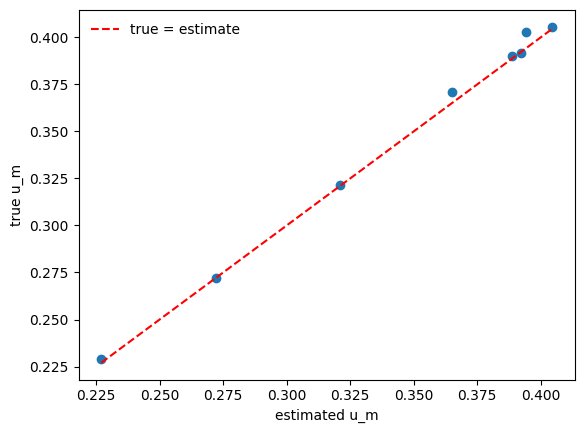

In [798]:
# u_m_sorted = np.sort(u_m)
# u_exact_sorted = np.sort(u_exact_amplitudes)
# errors = np.abs(u_m_sorted - u_exact_sorted)

# plt.bar(range(len(errors)), errors)
# plt.yscale('log')
# plt.xlabel("u_m index (sorted)")
# plt.ylabel("|estimated - true|")
# plt.title("u_m absolute errors")

plt.scatter(np.sort(u_m), np.sort(u_exact_amplitudes))
diag = np.linspace(np.min(u_m), np.max(u_m), 100)
plt.plot(diag, diag, "--", c="red", label="true = estimate")
plt.xlabel("estimated u_m")
plt.ylabel("true u_m")
plt.legend(frameon=False)


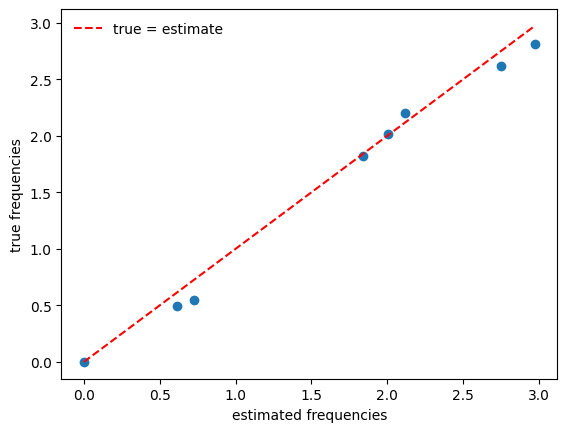

In [799]:
# phi_m_sorted = np.sort(phi_m)
# phi_exact_sorted = np.sort(u_exact_phases_rel)
# errors = np.abs(phi_m_sorted - phi_exact_sorted)

# plt.bar(range(len(errors)), errors)
# plt.yscale('log')
# plt.xlabel("phi_m index (sorted)")
# plt.ylabel("|estimated - true|")
# plt.title("phi_m absolute errors")


plt.scatter(np.sort(phi_m), np.sort(u_exact_phases_rel))
diag = np.linspace(np.min(phi_m), np.max(phi_m), 100)
plt.plot(diag, diag, "--", c="red", label="true = estimate")
plt.xlabel("estimated frequencies")
plt.ylabel("true frequencies")
plt.legend(frameon=False)

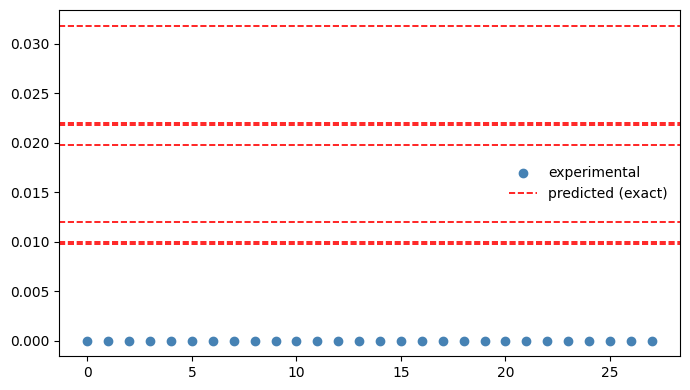

[0.0098 0.01   0.012  0.0198 0.0218 0.022  0.0318]
[1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12
 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12
 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12]


In [800]:
def calculate_dephasing_rates_upper_bound(gamma_list):
    # Calculate all possible combinations of dephasing
    nqubits = len(gamma_list)

    lambdas = []
    for size in range(1, nqubits + 1):
        for subset in combinations(range(nqubits), size):
            lambdas.append(sum(gamma_list[i] for i in subset))

    return np.unique(lambdas)

# Alternative given by claude: It's the same for TFIM
def predict_dephasing_rates_exact(egvecs, gamma_dep_list, sz_list):
    """
    Compute the exact predicted dephasing rate for each pair of eigenstates (m, n).

    For a Lindblad operator L_i = sqrt(gamma_i) * sigma_z[i], the coherence
    between eigenstates |m> and |n> decays at rate:

        lambda_mn = sum_i  gamma_i / 2 * (<m|sigma_z[i]|m> - <n|sigma_z[i]|n>)^2
    """
    N = egvecs.shape[0]

    # <m|sigma_z[i]|m> for each qubit i and eigenstate m — shape (n_qubits, N)
    sz_exp = np.array([
        np.real(np.diag(egvecs.conj().T @ sz @ egvecs))
        for sz in sz_list
    ])

    lambda_pred = np.zeros((N, N))
    for m in range(N):
        for n in range(m + 1, N):
            lambda_pred[m, n] = sum(
                gamma / 2 * (sz_exp[i, m] - sz_exp[i, n])**2
                for i, gamma in enumerate(gamma_dep_list)
            )
    return lambda_pred


possible_lambdas = calculate_dephasing_rates_upper_bound(t2_rates)
_exp_for_ops = LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, 0, dt)
exact_lambdas = predict_dephasing_rates_exact(egvecs, t2_rates, _exp_for_ops.npsz_list)
n_levels = 2**nqubits
pred_flat = np.array([exact_lambdas[m, n] for m in range(n_levels) for n in range(m+1, n_levels)])/2


plt.figure(figsize=(7, 4))
plt.scatter(range(len(lambdas)), lambdas/2, color='steelblue', zorder=3, label='experimental')
for i, rate in enumerate(possible_lambdas):
    plt.axhline(rate, color='red', linestyle='--', lw=1.2, label='predicted (exact)' if i == 0 else None)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

print(possible_lambdas)
print(lambdas)

## Next steps:

0. Fixed code to do the right thing --DONE

1. Extract frequency and epsilon from oscillations --DONE

2. Test for 2 qubit system. Modify class to take in number of qubits external target Hamiltonian --DONE

3. Test interferometry for 2, 3 qubit systems --DONE

4. Look at ordering of energies, like how Matthias does it --DONE

5.  Solve turnpike problem --DONE

6. Extract phases and amplitudes from Fourier analysis --DONE

7. Verify phases and amplitudes --DONE

8. Fix phases and amplitudes when information is incomplete --DONE

7. Add dephasing and decay noise --DONE

8. Open questions

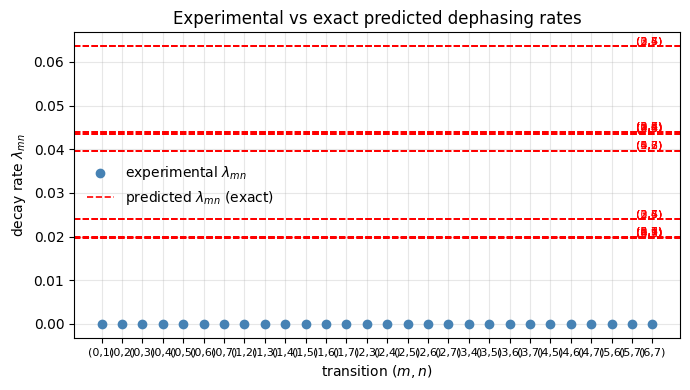

[1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12
 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12
 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12]


In [801]:
def calculate_theoretical_dephasing_rates(gamma_list):
    nqubits = len(gamma_list)
    lambdas = []
    for size in range(1, nqubits + 1):
        for subset in combinations(range(nqubits), size):
            lambdas.append(sum(gamma_list[i] for i in subset))
    return np.unique(lambdas)





# egvecs comes from cell 26: np.linalg.eigh(H_target) at s=1
_exp_for_ops = LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, 0, dt)
lambda_pred = predict_dephasing_rates_exact(egvecs, t2_rates, _exp_for_ops.npsz_list)

# Flatten upper triangle in row-major order
n_levels = 2**nqubits
pred_flat = np.array([lambda_pred[m, n] for m in range(n_levels) for n in range(m+1, n_levels)])
labels = [f'({m},{n})' for m in range(n_levels) for n in range(m+1, n_levels)]

# --- Plot: experimental lambdas as scatter, exact predicted as dashed lines ---
plt.figure(figsize=(7, 4))
plt.scatter(range(len(lambdas)), lambdas, color='steelblue', zorder=3, label='experimental $\\lambda_{mn}$')
for i, (rate, label) in enumerate(zip(pred_flat, labels)):
    plt.axhline(rate, color='red', linestyle='--', lw=1.2,
                label='predicted $\\lambda_{mn}$ (exact)' if i == 0 else None)
    plt.text(len(lambdas) - 0.5, rate, label, color='red', fontsize=8,
             va='bottom', ha='right')
plt.xticks(range(len(lambdas)), labels, fontsize=8)
plt.xlabel('transition $(m,n)$')
plt.ylabel('decay rate $\\lambda_{mn}$')
plt.title('Experimental vs exact predicted dephasing rates')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(lambdas)

In [802]:
# experimental_freqs, amplitudes = fourier_analysis(pc_list, tw_l, n_peaks = (2**nqubits)*(2**nqubits -1)//2)

# def fourier_analysis(pc_list, tw_l, n_peaks=15, prominence_threshold=0.01):
#     """
#     Fourier analysis extracting all significant frequencies.
    
#     Parameters
#     ----------
#     pc_list : array-like
#         Signal (e.g. ground state population over time).
#     tw_l : array-like
#         Time axis.
#     n_peaks : int
#         Maximum number of peaks to return.
#     prominence_threshold : float
#         Peaks below this fraction of the dominant peak magnitude are ignored.
    
#     Returns
#     -------
#     experimental_freqs : np.ndarray
#         Frequencies of the identified peaks, sorted by magnitude (descending).
#     amplitudes : np.ndarray
#         Corresponding amplitudes.
#     """
#     from scipy.signal import find_peaks

#     y = np.array(pc_list)
#     t = np.array(tw_l)
    
#     N = len(y)
#     dt = t[1] - t[0]
    
#     # FFT over positive frequencies only (skip DC at index 0)
#     spectrum = np.fft.fft(y)
#     freqs = np.fft.fftfreq(N, dt)
#     magnitude = np.abs(spectrum)
    
#     pos_idx = np.where(freqs > 0)[0]
#     pos_freqs = freqs[pos_idx]
#     pos_mag = magnitude[pos_idx]
    
#     # Find all local peaks — low distance/prominence to avoid missing broad peaks
#     peak_locs, _ = find_peaks(pos_mag, distance=1, prominence=0.01 * pos_mag.max())
#     if len(peak_locs) == 0:
#         peak_locs = np.array([np.argmax(pos_mag)])
    
#     # Filter by prominence relative to the dominant peak
#     threshold = prominence_threshold * pos_mag[peak_locs].max()
#     peak_locs = peak_locs[pos_mag[peak_locs] >= threshold]
    
#     # Sort by magnitude descending and take top n_peaks
#     order = np.argsort(pos_mag[peak_locs])[::-1]
#     peak_locs = peak_locs[order[:n_peaks]]
    
#     experimental_freqs = pos_freqs[peak_locs]
#     amplitudes = 2 * pos_mag[peak_locs] / N

#     # x-axis: crop just past the highest detected frequency
#     x_max = experimental_freqs.max() * 1.15

#     # --- Plots ---
#     plt.figure(figsize=(12, 5))
    
#     plt.subplot(1, 2, 1)
#     plt.plot(t, y, 'b-', linewidth=2)
#     plt.xlabel('Time')
#     plt.ylabel('Signal')
#     plt.title('Original Signal')
#     plt.grid(True, alpha=0.3)
    
#     plt.subplot(1, 2, 2)
#     plt.plot(pos_freqs, pos_mag, 'r-', linewidth=1.5)
#     colors = plt.cm.tab10.colors
#     # for i, (f, a) in enumerate(zip(experimental_freqs, amplitudes)):
#     #     plt.axvline(f, color=colors[i % len(colors)], linestyle='--',
#     #                 label=f'f{i+1}={f:.4f}, A={a:.4f}')
#     plt.xlabel('Frequency')
#     plt.ylabel('Magnitude')
#     plt.xlim(0, x_max)
#     plt.title('Fourier Transform')
#     #plt.legend(fontsize=8)
#     plt.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()
    
#     print("Identified frequencies:")
#     for i, (f, a) in enumerate(zip(experimental_freqs, amplitudes)):
#         print(f"  f{i+1} = {f:.6f},  amplitude = {a:.6f}")
    
#     return experimental_freqs, amplitudes
